In [1]:
import glob
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from lmfit import Model

Common function definitions go here

In [2]:
def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0

def shrink_array(arr, factor):
    """Re-bin an array by an integer factor.
    In the new array, each bin is the sum of the original bins.
    """
    old_shape = arr.shape
    new_shape = (old_shape[0] // factor, old_shape[1] // factor)
    new_arr = np.zeros(new_shape)
    for i in range(new_shape[0]):
        for j in range(new_shape[1]):
            new_arr[i, j] = np.sum(arr[i*factor:(i+1)*factor, j*factor:(j+1)*factor])
    return new_arr

def shrink_array_roll(arr, factor: int, offset_0: int = 0, offset_1: int = 0):
    """Offset the array by a given amount and then re-bin it with integer factor.
    """
    offset_0 = offset_0 % factor
    offset_1 = offset_1 % factor
    rolled_array = np.roll(arr, (offset_0, offset_1), axis=(0, 1))
    return shrink_array(rolled_array, factor)

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Parameter Definitions

In [3]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_04_07/afc_longterm/2D')
bin_size = 0.5  # unit: ns
storage_time = 1000  # unit: ns
files_to_include = 16

# data processing params
signal_idler_offset_guess = 454
idler_lim_input = (300, 1300)

Intermediate plotting definitions (primarily colormap)

In [4]:
cmap_name = 'magma'
cmap = plt.get_cmap(cmap_name)
new_cmap = truncate_colormap(cmap, minval=0.1, maxval=1.0)

In [5]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (4, 3)  # inches
dpi = 300

# colors
color_source = '#7570b3'
color_memory = '#d95f02'

# figure layout
vertical_ratios = (1, 1)  # for two plots
horizontal_ratios = (4, 2)
vertical_padding = 0.02
horizontal_padding = 0.02

## Load Data

In [6]:
all_files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
all_files.sort(key=sort_func)

# load data
all_counts = []
all_bins = []
all_freqs = []
file_numbers = []
for file in all_files:
    try:
        file_number = int(file.split('/')[-1].split('.')[0].split('_')[-1])
    except ValueError:
        file_number = 0
    file_numbers.append(file_number)

    data = np.load(file)
    counts = data['counts']
    bins = data['bins']
    freqs_start = data['freq_start']
    freqs_end = data['freq_end']
    all_counts.append(counts)
    all_bins.append(bins)
    all_freqs.append((freqs_start, freqs_end))

In [7]:
all_hist = np.sum(all_counts[:files_to_include], axis=0)

## Recovery of Bidirectional Histograms using Diagonal Sums

These cells also identify the primary candidate diagonal for echo analysis

In [8]:
# compute diagonals
start_diag = 0
end_diag = all_hist.shape[0] - idler_lim_input[1]
offsets = np.arange(start_diag, end_diag, 1)
offsets = offsets * -1
diags = [np.diagonal(all_hist, offset=offset)[idler_lim_input[0]:idler_lim_input[1]]
         for offset in offsets]
diag_sum = np.sum(diags, axis=1)

# convert from offset to signal-idler arrival time in ns
# bin size for experiment is 500 ps
time_arr = offsets * -bin_size

# get input and echo counts coincidence histogram
# echo is shifted by 1 us to coincide temporally with input
input_idx = np.where(np.logical_and(time_arr > (signal_idler_offset_guess*0.5)-25,
                                    time_arr < (signal_idler_offset_guess*0.5)+25))[0]
echo_idx = input_idx + int(storage_time / bin_size)

input_center = time_arr[np.argmax(diag_sum)]

echo_center = 2456  # guessing this value based on the echo histogram

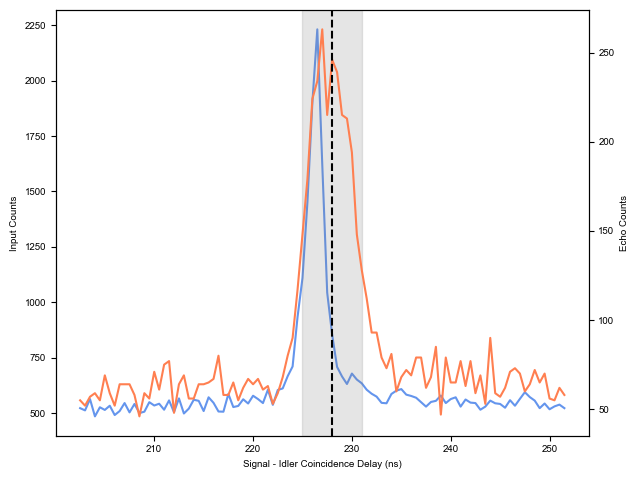

In [9]:
# plot diagonals and zoom on certain regions
fig, ax = plt.subplots()
ax_r = ax.twinx()
ax.plot(time_arr[input_idx], diag_sum[input_idx],
        color='cornflowerblue')
ax_r.plot(time_arr[input_idx], diag_sum[echo_idx],
          color='coral')
ax_r.axvline(time_arr[echo_center]-1e3,
             color='k', ls='--')
ax_r.axvspan(time_arr[echo_center]-1e3 - 3, time_arr[echo_center]-1e3 + 3,
             color='gray', alpha=0.2)
ax.set_ylabel('Input Counts')
ax_r.set_ylabel('Echo Counts')
ax.set_xlabel('Signal - Idler Coincidence Delay (ns)')
fig.tight_layout()

## Square Rebinning

Here, we rebin the histogram with square bins, such that the center of the coincidence peak lies diagonally across one square bin.

First, do the rebinning

In [10]:
rebin_factors = np.arange(4, 41, 1)  # unit: no. of bins
rebinned_hists = []

for factor in rebin_factors:
    offset_0 = -echo_center
    rebinned_array = shrink_array_roll(all_hist, factor=factor, offset_0=offset_0)
    rebinned_hists.append(rebinned_array)

Next, we plot the diagonal for each to extract $g^{(2)}$ and error rate

In [11]:
all_diagonal_sums = []
for factor, hist in zip(rebin_factors, rebinned_hists):
    end_diag = hist.shape[0] - (idler_lim_input[1] // factor)
    offsets = np.arange(0, end_diag, 1)
    offsets = offsets * -1
    diags = [np.diagonal(hist, offset=offset)[idler_lim_input[0]//factor:idler_lim_input[1]//factor]
             for offset in offsets]
    diag_sum = np.sum(diags, axis=1)
    all_diagonal_sums.append(diag_sum)

In [12]:
contrast_vals = []
contrast_err = []
center_idxs = []
width = 200  # unit: ns

for factor, diagonal in zip(rebin_factors, all_diagonal_sums):
    bin_size_time = factor * bin_size
    time_center = echo_center * bin_size
    time_bins = np.arange(len(diagonal)) * bin_size_time
    idx_to_analyze = np.where(np.logical_and(time_bins >= time_center - width/2, time_bins <= time_center + width/2))[0]
    counts_to_analyze = diagonal[idx_to_analyze]
    center_idx = np.argmax(counts_to_analyze)
    center_idxs.append(center_idx)
    center_counts = np.max(counts_to_analyze)
    bg_left_counts = counts_to_analyze[center_idx - 1]
    bg_right_counts = counts_to_analyze[center_idx + 1]
    bg_counts = (bg_left_counts + bg_right_counts) / 2

    contrast = center_counts / bg_counts
    contrast_vals.append(contrast)

    center_err = np.sqrt(center_counts)
    bg_err = np.sqrt(bg_left_counts + bg_right_counts) / 2
    contrast_err.append(contrast * np.sqrt((center_err / center_counts) ** 2 + (bg_err / bg_counts) ** 2))

Text(0, 0.5, 'Center Bin Contrast')

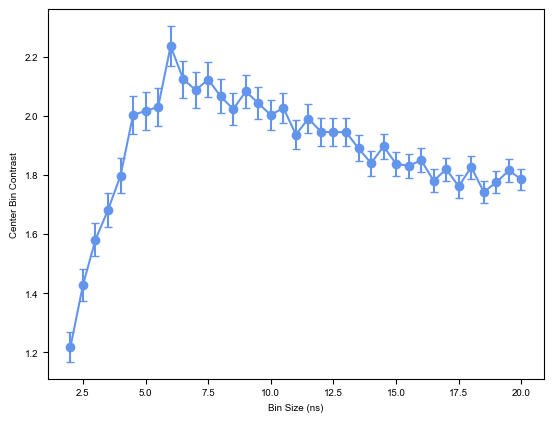

In [13]:
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_vals, yerr=contrast_err,
             marker='o', capsize=3, color='cornflowerblue')
plt.xlabel('Bin Size (ns)')
plt.ylabel('Center Bin Contrast')

In [14]:
contrast_vals = np.array(contrast_vals)
contrast_error = 1 / (contrast_vals + 1)
error_yerr = (contrast_err / contrast_vals) * (1 / (contrast_vals + 1))

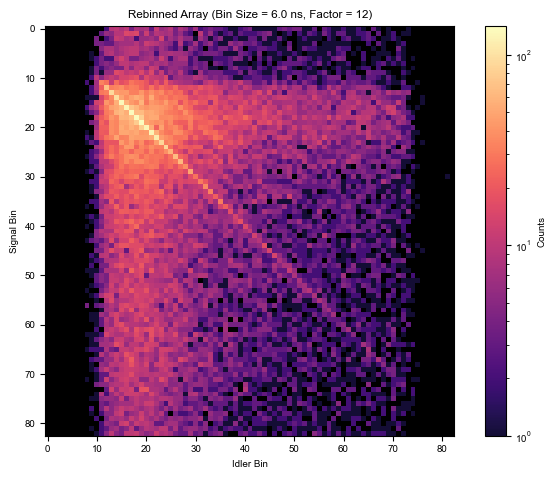

In [15]:
idx_to_plot = np.argmax(contrast_vals)
factor = rebin_factors[idx_to_plot]
rebinned_array = rebinned_hists[idx_to_plot]

# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess + 2000) // factor + 1
signal_end = (idler_lim_input[1] + signal_idler_offset_guess + 2000) // factor + 1
idler_start = idler_lim_input[0] // factor
idler_end = idler_lim_input[1] // factor
echo_zoom = rebinned_array[signal_start:signal_end, idler_start:idler_end]

time_bins = np.arange(len(echo_zoom)) * factor * bin_size

# plot log scale
plt.imshow(echo_zoom, cmap=new_cmap,
           norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
plt.gca().set_facecolor('black')
plt.xlabel('Idler Bin')
plt.ylabel('Signal Bin')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {factor * bin_size} ns, Factor = {factor})')
plt.tight_layout()
plt.show()

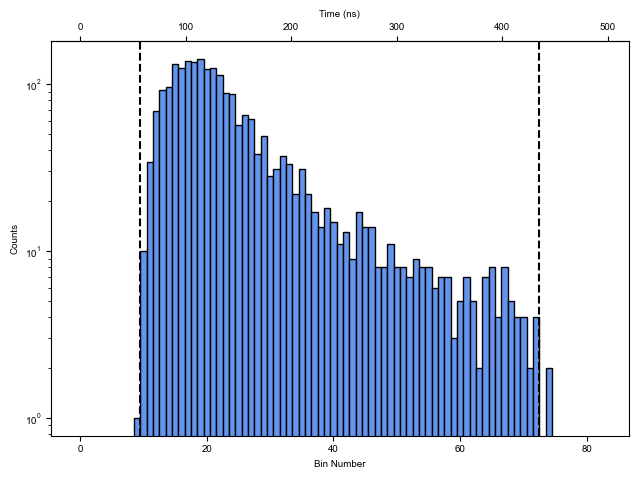

In [16]:
time_bin_diagonal = np.diagonal(echo_zoom)
time_bin_off_diagonal_right = np.diagonal(echo_zoom, offset=1)
time_bin_off_diagonal_left = np.diagonal(echo_zoom, offset=-1)
off_diagonal = (time_bin_off_diagonal_right + time_bin_off_diagonal_left) / 2
bin_numbers = np.arange(len(time_bin_diagonal))

# functions for axes
def bin_to_time(bin_number):
    return bin_number * factor * bin_size

def time_to_bin(time):
    return time / (factor * bin_size)

fig, ax = plt.subplots()
ax.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
# ax.bar(bin_numbers[1:], off_diagonal, width=1, color='coral', edgecolor='k')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Counts')
ax.set_yscale('log')
sec_ax = ax.secondary_xaxis('top', functions=(bin_to_time, time_to_bin))
sec_ax.set_xlabel('Time (ns)')

ax.axvline(10 - 0.5, color='k', ls='--')
ax.axvline(73 - 0.5, color='k', ls='--')

fig.tight_layout()

## Entropy Analysis

In [17]:
bin_nums = np.arange(10, 70, 1, dtype=int)
min_start_idx = 0
max_max_start_idx = len(time_bin_diagonal) - min(bin_nums)
entropies = np.empty((len(bin_nums), max_max_start_idx+1))
entropies[:] = np.nan
entropies_scaled = np.empty((len(bin_nums), max_max_start_idx+1))
entropies_scaled[:] = np.nan

for i, bin_num in enumerate(bin_nums):
    max_start_idx = len(time_bin_diagonal) - bin_num

    for j, start_idx in enumerate(range(min_start_idx, max_start_idx)):
        end_idx = start_idx + bin_num
        time_bins_to_analyze = time_bin_diagonal[start_idx:end_idx]
        counts_tot = np.sum(time_bins_to_analyze)
        amplitudes = time_bins_to_analyze / counts_tot
        entropy = 0
        for amplitude in amplitudes:
            if amplitude > 0:
                entropy -= amplitude * np.log2(amplitude)

        entropies[i, j] = entropy
        entropies_scaled[i, j] = entropy * counts_tot

In [18]:
max_total_entropy = np.nanmax(entropies_scaled, axis=1)
max_entropy_idx = np.nanargmax(entropies_scaled, axis=1)
max_entropy = np.array([entropies[i, max_entropy_idx[i]] for i in range(len(bin_nums))])

In [19]:
for frame_size, max_idx, entropy_per in zip(bin_nums, max_entropy_idx, max_entropy):
    print(frame_size, max_idx, entropy_per)

10 13 3.3090212420291145
11 13 3.442054710369876
12 13 3.5641327181645286
13 12 3.6702091153514624
14 12 3.76323633104883
15 12 3.8557689992227524
16 12 3.94196882676863
17 12 4.008568412313784
18 12 4.080838136523158
19 11 4.139425356200911
20 11 4.19076595460258
21 12 4.246052187394274
22 11 4.300016513568907
23 11 4.351744319149692
24 11 4.392181121396577
25 11 4.440071325134277
26 11 4.478878132677945
27 11 4.511575637226319
28 11 4.540120990628705
29 11 4.573117955469461
30 11 4.602192802289062
31 11 4.625695413059161
32 11 4.651681739491455
33 10 4.673314975364867
34 11 4.701988824397519
35 11 4.728404221134061
36 11 4.754533650623709
37 10 4.775308631172502
38 10 4.793018184225371
39 11 4.811951486464452
40 10 4.832284010545591
41 10 4.849628649748265
42 10 4.866865042113312
43 10 4.882478693032603
44 10 4.900934803960143
45 10 4.917853420187147
46 10 4.9346681770361345
47 10 4.948340054950614
48 10 4.963507216359911
49 10 4.97859314830434
50 10 4.986682771037319
51 10 4.9984697

## $g(2)$ Analysis

First, reconstruct bidirectional histogram for different subsets of the echo pulse

In [20]:
start_idx = 10
num_bins = frame_size

end_idx = start_idx + num_bins

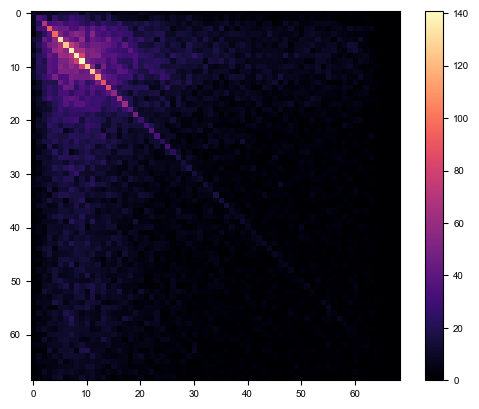

In [21]:
echo_center = echo_zoom[start_idx:end_idx, start_idx:end_idx]
plt.imshow(echo_center, cmap='magma')
plt.colorbar()

In [22]:
all_diags_sum = []
for i in range(num_bins):
    echo_region = echo_center[num_bins-i-1:, num_bins-i-1:]
    diags = [np.diagonal(echo_region, offset=offset) for offset in range(-i, i+1)]
    diags_sum = [np.sum(diag) for diag in diags]
    all_diags_sum.append(diags_sum)

### Fitting of $g(2)$ function

Extract using exponential + triangle (in small region around center)

In [23]:
def g2_fit_func(x, bg_w, bg_h, amplitude, T_1, T_2):
    """Another fitting function for cavity decay.

    Fit as two exponentials with a constant background offset.

    Args:
        x (np.ndarray): time-domain x-values
        bg_w (float): background triangular width
        bg_h (float): background triangular height
        amplitude (float): amplitude of coincidence peak
        T_1 (float): decay constant for right (positive) side of peak
        T_2 (float): decay constant for left (negative) side of peak

    Return:
        np.ndarray: coincidence histogram
    """
    right_decay = np.heaviside(x, 0.5) * np.exp(-x / T_1)
    left_decay = np.heaviside(-x, 0.5) * np.exp(x / T_2)
    bg_arr = bg_h * (1 - (np.abs(x) / bg_w))
    return (amplitude * right_decay) + (amplitude * left_decay) + bg_arr

def x_axis_helper(array):
    array_len = len(array)
    return np.arange(array_len) - (array_len - 1) / 2

model = Model(g2_fit_func)

In [32]:
g2s = []
g2_errs = []
total_counts = []
cars = []
# fit_range = np.array(range(30, num_bins))
fit_range = np.arange(50, num_bins, 1, dtype=int)

for data_idx_to_fit in fit_range:
    x_data = x_axis_helper(all_diags_sum[data_idx_to_fit])
    idx_to_fit = np.where(np.logical_and(x_data > -10, x_data < 10))[0]
    x_data_to_fit = x_data[idx_to_fit]
    y_data_to_fit = np.array(all_diags_sum[data_idx_to_fit])[idx_to_fit]
    center_idx = len(idx_to_fit)//2
    center_counts = y_data_to_fit[center_idx]
    total_counts.append(center_counts)  # record number of detections in center bin
    accidentals = (y_data_to_fit[center_idx+1] + y_data_to_fit[center_idx-1]) / 2
    cars.append(center_counts / accidentals)

    bg_h_guess = 2 * y_data_to_fit[0]
    amplitude_guess = np.max(y_data_to_fit) - bg_h_guess
    bg_w_guess = 50

    res = model.fit(y_data_to_fit, x=x_data_to_fit,
                    bg_w=bg_w_guess, bg_h=bg_h_guess, amplitude=amplitude_guess, T_1=1, T_2=1)

    amplitude = res.params['amplitude'].value
    amplitude_err = res.params['amplitude'].stderr
    bg_h = res.params['bg_h'].value
    bg_h_err = res.params['bg_h'].stderr
    g2 = (amplitude + bg_h) / bg_h

    numerator = amplitude + bg_h
    numerator_err = np.sqrt(amplitude_err**2 + bg_h_err**2)
    g2_err = g2 * np.sqrt((numerator_err / numerator) ** 2 + (bg_h_err / bg_h) ** 2)

    g2s.append(g2)
    g2_errs.append(g2_err)

Text(0, 0.5, 'Total Detection Events')

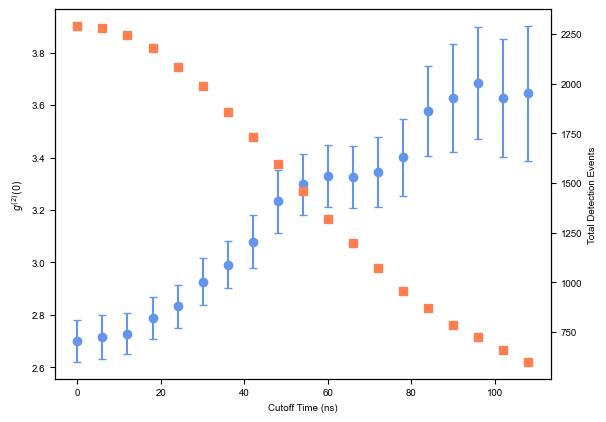

In [33]:
cutoff_time = (num_bins - (fit_range+1)) * factor * bin_size

fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.errorbar(cutoff_time, g2s, yerr=g2_errs, fmt='o', capsize=3, color='cornflowerblue')
ax2.plot(cutoff_time, total_counts, ls='', marker='s', color='coral',)

ax.set_xlabel('Cutoff Time (ns)')
ax.set_ylabel('$g^{(2)}(0)$')
ax2.set_ylabel('Total Detection Events')

## Do CAR instead of g(2)

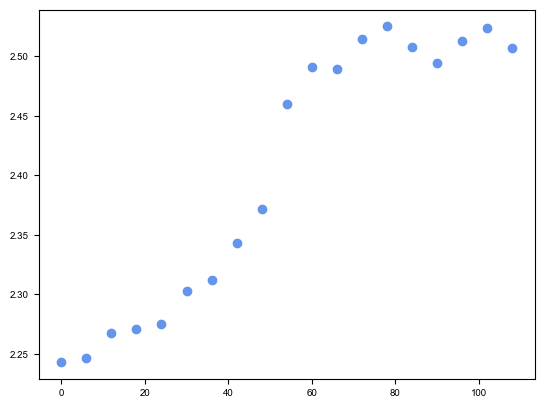

In [34]:
plt.plot(cutoff_time, cars, ls='', marker='o', color='cornflowerblue')

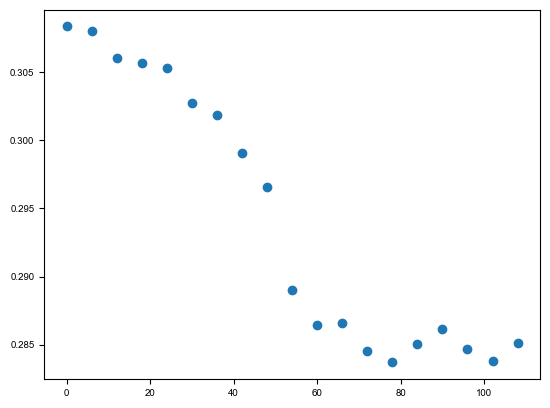

In [35]:
frame_size_bin_error = 1 / (np.array(cars) + 1)

plt.plot(cutoff_time, frame_size_bin_error, ls='', marker='o')

## Final Plotting

In [36]:
figsize = (7, 3)

# colors
color_source = '#7570b3'
color_source_2 = 'darkgray'
color_memory = '#d95f02'
color_memory_2 = 'darkgray'

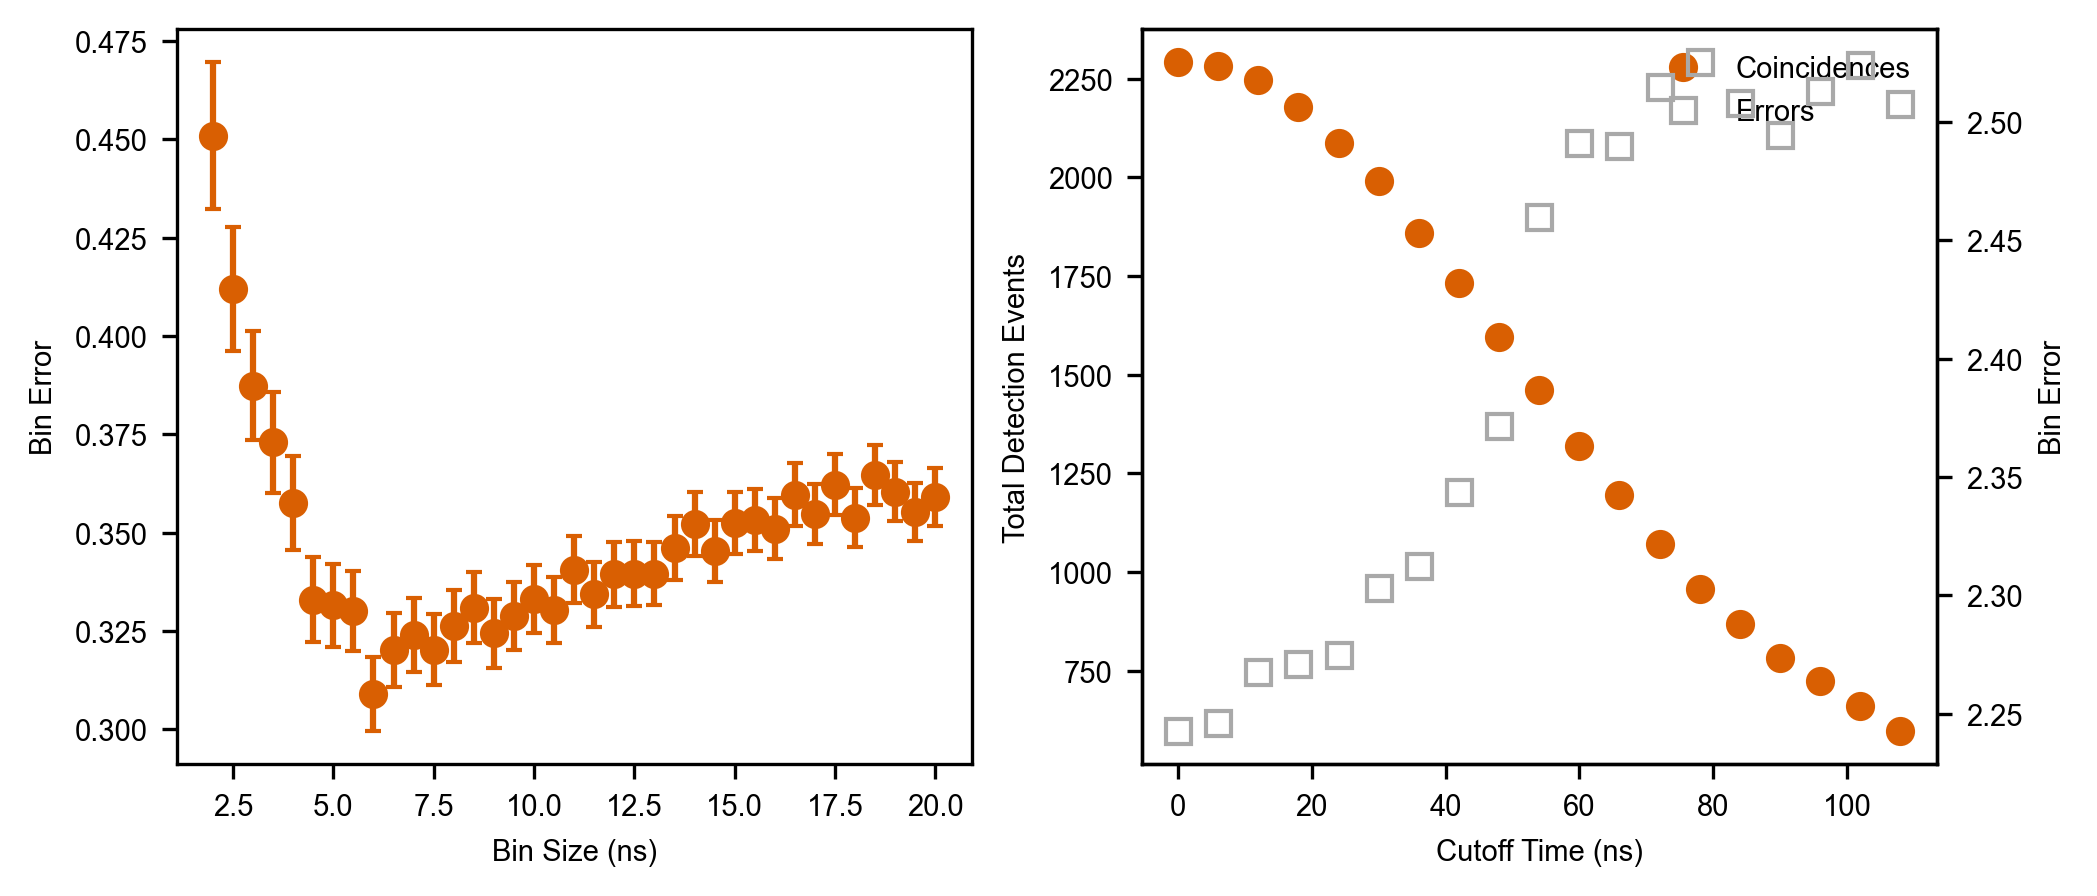

In [37]:
fig, axs = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

axs[0].errorbar(np.array(rebin_factors) * bin_size, contrast_error, yerr=error_yerr,
                ls='', marker='o', capsize=2, color=color_memory)
axs[0].set_xlabel('Bin Size (ns)')
axs[0].set_ylabel('Bin Error')

axs1_r = axs[1].twinx()
# lns_coinc = axs[1].plot(cutoff_time, total_counts,
#                         ls='', marker='s', color=color_memory_2, markerfacecolor='none', markeredgewidth=1,
#                         label='Total Coincidences')
# lns_g2 = axs1_r.errorbar(cutoff_time, g2s, yerr=g2_errs, fmt='o', capsize=3, color=color_memory)
lns_coinc = axs[1].plot(cutoff_time, total_counts,
                        ls='', marker='o', color=color_memory,
                        label='Coincidences')
lns_car = axs1_r.plot(cutoff_time, cars,
                      ls='', marker='s', color=color_memory_2, markerfacecolor='none', markeredgewidth=1,
                      label='Errors')

lns = lns_coinc + lns_car
labs = [l.get_label() for l in lns]
axs[1].legend(lns, labs, frameon=False)
axs[1].set_xlabel('Cutoff Time (ns)')
axs1_r.set_ylabel('Bin Error')
axs[1].set_ylabel('Total Detection Events')

fig.tight_layout()

In [30]:
fig.savefig('supp_qudit_analysis.pdf')